In [1]:
!which python

/usr/local/bin/python


In [2]:
# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd

# Importing  tools for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import evaluation metric libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Library used for data preprocessing
from sklearn.preprocessing import LabelEncoder

# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold

# Library used for ML Model implementation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score


# import xgboost as xgb


# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# import dataset
from sklearn.datasets import load_iris

In [3]:
sns.set()

In [4]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target #classification needs a target colmunn
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [5]:
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Number of rows are:  150
Number of columns are:  5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


Label the data,
Data Cleaning and Preprocessing: Handle missing values, outliers, and normalize or scale the data to ensure quality.
Feature Engineering and Selection: Choose the most relevant variables (features) that help differentiate between classes to enhance efficiency.
I probably have to split the data into training and testing sets
Choose a model to run based on the dataset
Model Training: Train the classifier by fitting it to the training data so it can learn patterns between features and labels
Model Evaluation & Tuning: Test the model's performance on the test set using metrics like accuracy, confusion matrix, precision, and recall, then tune hyperparameters to improve results.
Deployment and Monitoring: Deploy the final model to make predictions on new data and consistently monitor its performance over time.


# Preprocessing the data


In [7]:
dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print("Number of duplicate rows: ", dup)

Number of duplicate rows:  1


In [8]:
#Missing values/null values
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0


In [9]:
print(df.nunique())

sepal length (cm)    35
sepal width (cm)     23
petal length (cm)    43
petal width (cm)     22
target                3
dtype: int64


What do I know about this dataset?

- There are 5 columns and 150 rows
- There are 3 classes (target variables)
- No duplicate values exist
- No Null values exist

In [10]:
df.columns.tolist()

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)',
 'target']

In [11]:
df.describe(include= 'all')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Data Wrangling

In [12]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
# df.iloc[0]

What manipulations do I need?

None here, the data is cleaned. We will use all the columns. There are no outliers and we seem to have a normal distrubution, according to .describe(),

# Data Vizualization, EDA: Storytelling & Experimenting : Understand the relationships between variables

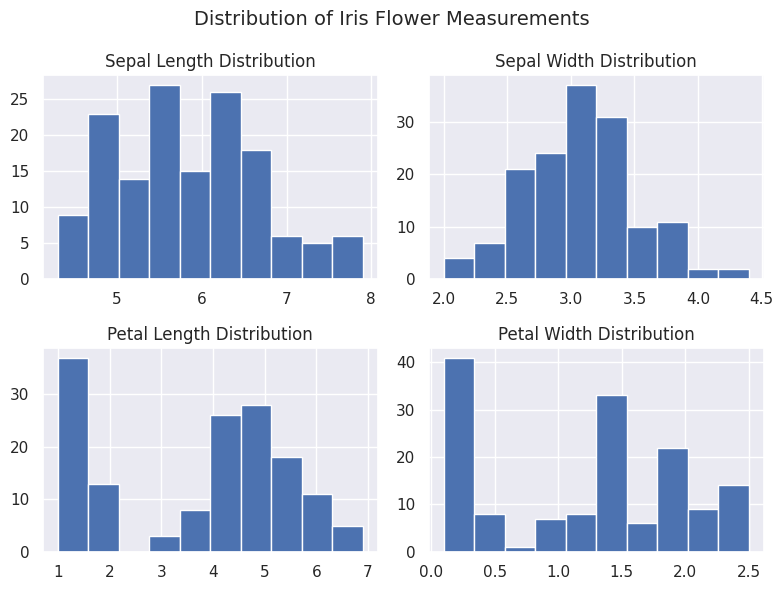

In [14]:
# Univariate Analysis
# Histograms: Show how data values are distributed.

# 4 features, 1 target column

plt.figure(figsize=(8, 6)) #create the plot in the grid
plt.suptitle('Distribution of Iris Flower Measurements', fontsize=14)

# Create a 2x2 grid of subplots
plt.subplot(2, 2, 1)  # Subplot 1 (Top-Left) #subplot is the location of the plot in the grid
plt.hist(df['sepal length (cm)'])
plt.title('Sepal Length Distribution')

plt.subplot(2, 2, 2)  # Subplot 2 (Top-Right)
plt.hist(df['sepal width (cm)'])
plt.title('Sepal Width Distribution')

plt.subplot(2,2,3)
plt.hist(df['petal length (cm)'])
plt.title('Petal Length Distribution')

plt.subplot(2,2,4)
plt.hist(df['petal width (cm)'])
plt.title('Petal Width Distribution')

#display the subplots/adjust
plt.tight_layout()  # Helps in adjusting the layout
plt.show()


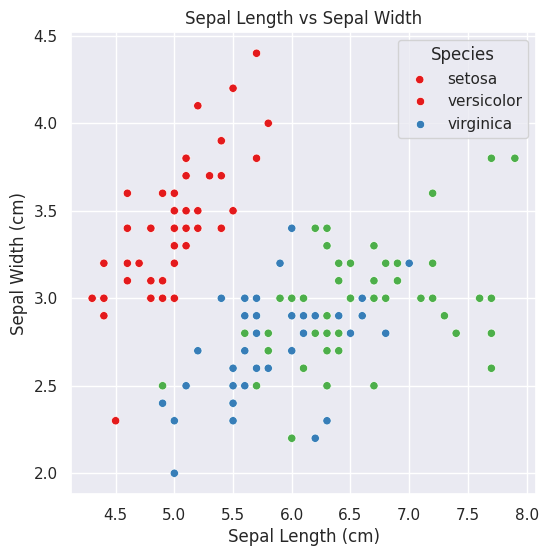

In [15]:
#Scatterplot: Show the relationship between two features.
plt.figure(figsize=(6, 6))
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='target', data=df, palette='Set1')
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species', labels=iris.target_names)
plt.show()


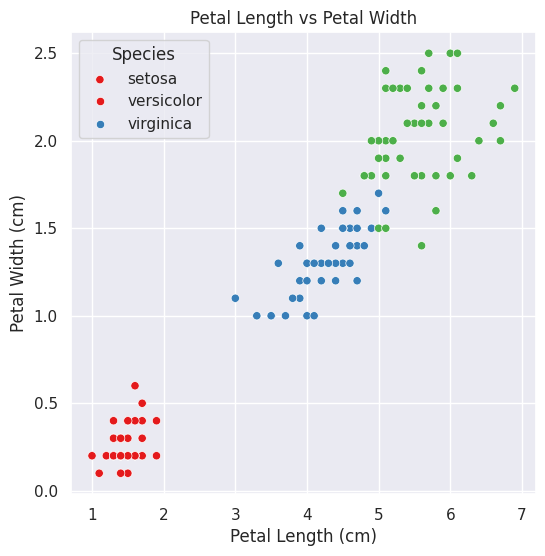

In [16]:
#Petal width vs petal length
plt.figure(figsize=(6, 6))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='target', data=df, palette='Set1')
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species', labels=iris.target_names)
plt.show()

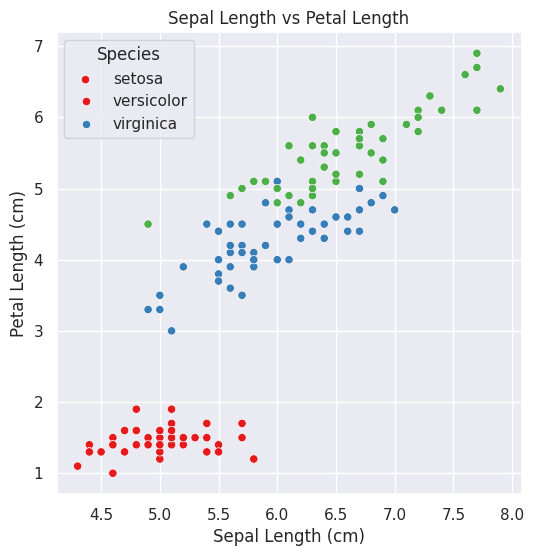

In [17]:
# Sepal Length vs Petal Length
plt.figure(figsize=(6, 6))
sns.scatterplot(x='sepal length (cm)', y='petal length (cm)', hue='target', data=df, palette='Set1')
plt.title('Sepal Length vs Petal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species', labels=iris.target_names)
plt.show()

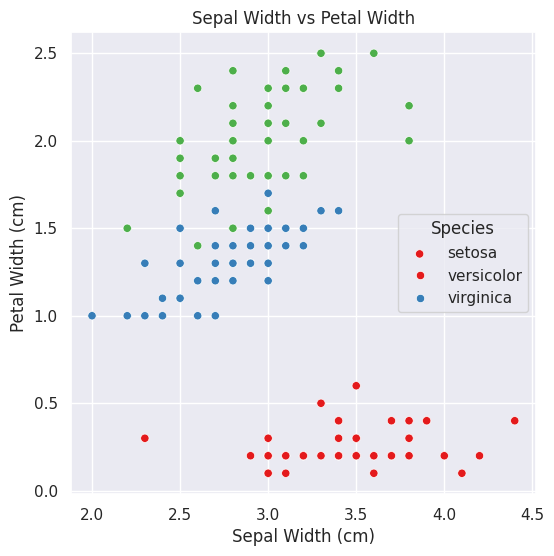

In [18]:
#septal width vs petal width
plt.figure(figsize=(6, 6))
sns.scatterplot(x='sepal width (cm)', y='petal width (cm)', hue='target', data=df, palette='Set1')
plt.title('Sepal Width vs Petal Width')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species', labels=iris.target_names)
plt.show()

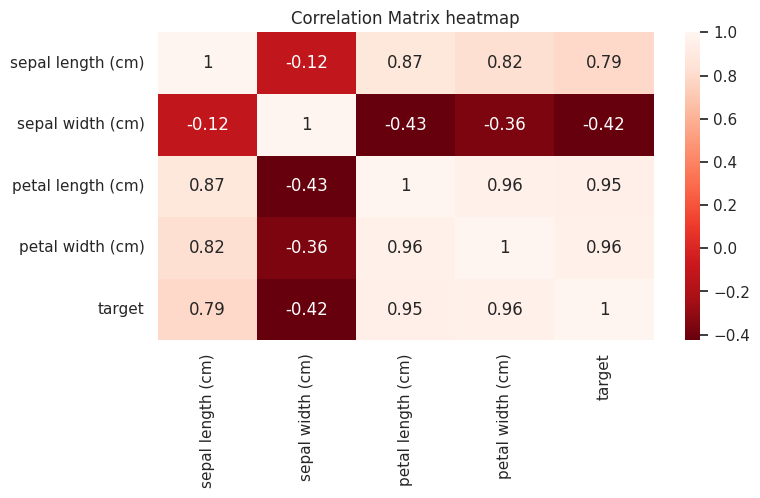

In [19]:
#Heatmap: Show the correlation between features.
corr_matrix = df.corr()
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap='Reds_r')
plt.title('Correlation Matrix heatmap')
plt.show()

# Feature Engineering

In [20]:
# Target feature is already in numeric form, so no need for label encoding

#Define the data (x, y)

x = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target variable (species: 0 for setosa, 1 for versicolor, 2 for virginica)

In [21]:
#Split the data

# Splitting the data to train and test
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2)

In [22]:
# Checking the train distribution of dependent variable
unique_elements, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique_elements, counts))) #y_train is the dependent variable, let's see how many counts/flowers each class has



{np.int64(0): np.int64(42), np.int64(1): np.int64(42), np.int64(2): np.int64(36)}


# ML Models

In [23]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    '''The function will take model, x train, x test, y train, y test
    and then it will fit the model, then make predictions on the trained model,
    it will then print roc-auc score of train and test, then plot the roc, auc curve,
    print confusion matrix for train and test, then print classification report for train and test,
    then plot the feature importances if the model has feature importances,
    and finally it will return the following scores as a list:
    recall_train, recall_test, acc_train, acc_test, F1_train, F1_test
    '''

    # Fit the model to the training data
    model.fit(x_train,y_train)

    #make predictions on the test data, get results from the test data
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)


    # calculate classification report
    cr_train = classification_report(y_train, y_pred_train, output_dict=True)
    cr_test = classification_report(y_test, y_pred_test, output_dict=True)
    print("\nTrain Classification Report:")
    crt = pd.DataFrame(cr_train).T
    print(crt.to_markdown())
    print("\nTest Classification Report:")
    crt2 = pd.DataFrame(cr_test).T
    print(crt2.to_markdown())

    precision_train = cr_train['weighted avg']['precision']
    precision_test = cr_test['weighted avg']['precision']

    recall_train = cr_train['weighted avg']['recall']
    recall_test = cr_test['weighted avg']['recall']

    acc_train = accuracy_score(y_true = y_train, y_pred = y_pred_train)
    acc_test = accuracy_score(y_true = y_test, y_pred = y_pred_test)

    F1_train = cr_train['weighted avg']['f1-score']
    F1_test = cr_test['weighted avg']['f1-score']

    model_score = [precision_train, precision_test, recall_train, recall_test, acc_train, acc_test, F1_train, F1_test ]

    # calculate confusion matrix
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_test = confusion_matrix(y_test, y_pred_test)

    fig, ax = plt.subplots(1, 2, figsize=(11,4))

    print("\nConfusion Matrix:")
    sns.heatmap(cm_train, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[0])
    ax[0].set_xlabel("Predicted Label")
    ax[0].set_ylabel("True Label")
    ax[0].set_title("Train Confusion Matrix")

    sns.heatmap(cm_test, annot=True, xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], cmap="Oranges", fmt='.4g', ax=ax[1])
    ax[1].set_xlabel("Predicted Label")
    ax[1].set_ylabel("True Label")
    ax[1].set_title("Test Confusion Matrix")

    plt.tight_layout() #here for formatting reasons
    plt.show()


    return model_score

In [24]:
# Create a score dataframe
score = pd.DataFrame(index = ['Precision Train', 'Precision Test','Recall Train','Recall Test','Accuracy Train', 'Accuracy Test', 'F1 macro Train', 'F1 macro Test'])


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        42 |
| 1            |           1 |        1 |          1 |        42 |
| 2            |           1 |        1 |          1 |        36 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       120 |
| weighted avg |           1 |        1 |          1 |       120 |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        |  8        |
| 1            |    0.888889 | 1        |   0.941176 |  8        |
| 2            |    1        | 0.928571 |   0.962963 | 14        |
| accuracy     |    0.966667 | 0.966667 |   0.966667 |  0.966667 |
| m

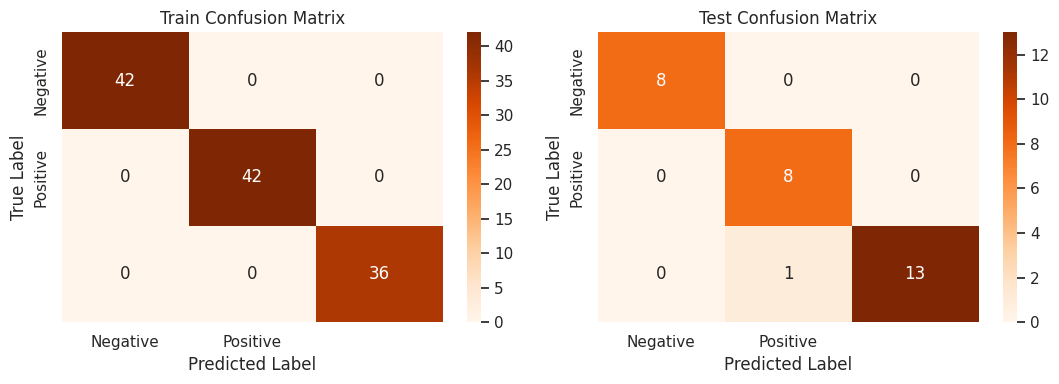

In [25]:
#Decision Trees

d_trees = DecisionTreeClassifier(random_state=20)

# Visualizing evaluation Metric Score chart
dt_score = evaluate_model(d_trees, x_train, x_test, y_train, y_test)

In [26]:
#Update the Evaulation Metric Score Chart
score['Decision Tree'] = dt_score

In [27]:
# Random Forest

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        42 |
| 1            |           1 |        1 |          1 |        42 |
| 2            |           1 |        1 |          1 |        36 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       120 |
| weighted avg |           1 |        1 |          1 |       120 |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        |  8        |
| 1            |    0.888889 | 1        |   0.941176 |  8        |
| 2            |    1        | 0.928571 |   0.962963 | 14        |
| accuracy     |    0.966667 | 0.966667 |   0.966667 |  0.966667 |
| m

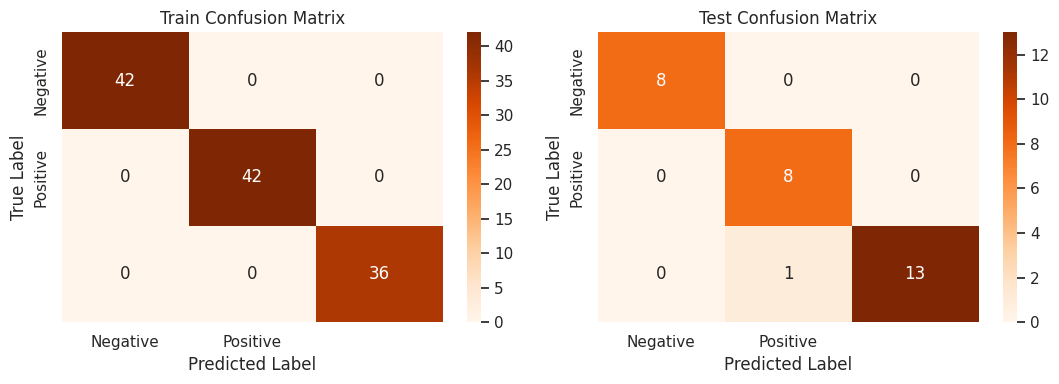

In [28]:
rf_score = evaluate_model(rf_model, x_train, x_test, y_train, y_test)

In [29]:
score['Random Forest'] = rf_score

In [30]:
#Support Vector Machine (SVM)

svm_model = SVC(kernel='linear', random_state=0, probability=True)


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        |    42     |
| 1            |    0.97561  | 0.952381 |   0.963855 |    42     |
| 2            |    0.945946 | 0.972222 |   0.958904 |    36     |
| accuracy     |    0.975    | 0.975    |   0.975    |     0.975 |
| macro avg    |    0.973852 | 0.974868 |   0.974253 |   120     |
| weighted avg |    0.975247 | 0.975    |   0.975021 |   120     |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |         8 |
| 1            |           1 |        1 |          1 |         8 |
| 2            |           1 |        1 |          1 |        14 |
| accuracy     |           1 |        1 |          1 |         1 |
| m

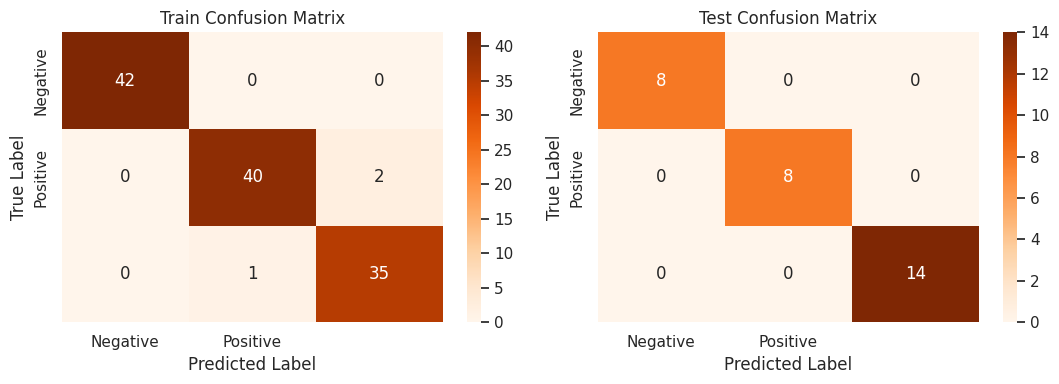

In [31]:
svm_score = evaluate_model(svm_model, x_train, x_test, y_train, y_test)

In [32]:
score['SVM'] = svm_score

In [33]:
score

,Decision Tree,Random Forest,SVM
Precision Train,1.000000,1.000000,0.975247
Precision Test,0.970370,0.970370,1.000000
Recall Train,1.000000,1.000000,0.975000
Recall Test,0.966667,0.966667,1.000000
Accuracy Train,1.000000,1.000000,0.975000
Accuracy Test,0.966667,0.966667,1.000000
F1 macro Train,1.000000,1.000000,0.975021
F1 macro Test,0.967030,0.967030,1.000000


# Let's practice with fine tuning the hyperparameters of the Random Forest model using GridSearchCV


In [34]:
rfecv = RFECV(estimator=rf_model, step=1, cv=StratifiedKFold(10), scoring='roc_auc_ovr',min_features_to_select=2)
# this finds the total number of features that are important for the model, then it selects the best features based on the ROC AUC score, works recusrively
#Output: a reduced set of the most important features

pipeline = Pipeline([
    ('feature_selection', rfecv),
    ('classification', rf_model)
])

In [40]:
# Define the parameter grid
param_grid = {
    'classification__n_estimators': [100, 200],
    'classification__max_features': ['sqrt'],
    'classification__max_depth': [5, 7],
    'classification__criterion': ['gini']
}

In [41]:
# Define the GridSearchCV
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=StratifiedKFold(5), scoring='roc_auc_ovr', n_jobs=-1)

# Fit the GridSearchCV to the data
grid_search.fit(x_train, y_train)
#Cross-Validation is a technique used to evaluate the performance of a machine learning model by splitting the data into multiple subsets (folds) and training/testing the model on different combinations of these subsets.
# It helps to ensure that the model's performance is not dependent on a specific train-test split and provides a more robust estimate of its generalization ability.
# In this case, we are using StratifiedKFold with 10 folds,which means the data will be split into 10 subsets while maintaining the class distribution in each fold.
# The GridSearchCV will then train and evaluate the model on each combination of hyperparameters specified in the param_grid, using the ROC AUC score as the evaluation metric.

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)


Best parameters found:  {'classification__criterion': 'gini', 'classification__max_depth': 5, 'classification__max_features': 'sqrt', 'classification__n_estimators': 100}
Best cross-validation score:  0.9951746323529411


In [42]:
# Predict on the test set
y_pred = grid_search.predict(x_test)
y_pred_proba = grid_search.predict_proba(x_test)

In [43]:
# Evaluate the model

roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print("ROC AUC Score on test data: ", roc_auc)

ROC AUC Score on test data:  1.0


In [44]:
best_params = grid_search.best_params_
best_params_clean = {k.replace('classification__', ''): v
                     for k, v in best_params.items()}


In [45]:
rf_model_opt = RandomForestClassifier(**best_params_clean, random_state=42, class_weight='balanced')


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        42 |
| 1            |           1 |        1 |          1 |        42 |
| 2            |           1 |        1 |          1 |        36 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |       120 |
| weighted avg |           1 |        1 |          1 |       120 |

Test Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |    1        | 1        |   1        |  8        |
| 1            |    0.888889 | 1        |   0.941176 |  8        |
| 2            |    1        | 0.928571 |   0.962963 | 14        |
| accuracy     |    0.966667 | 0.966667 |   0.966667 |  0.966667 |
| m

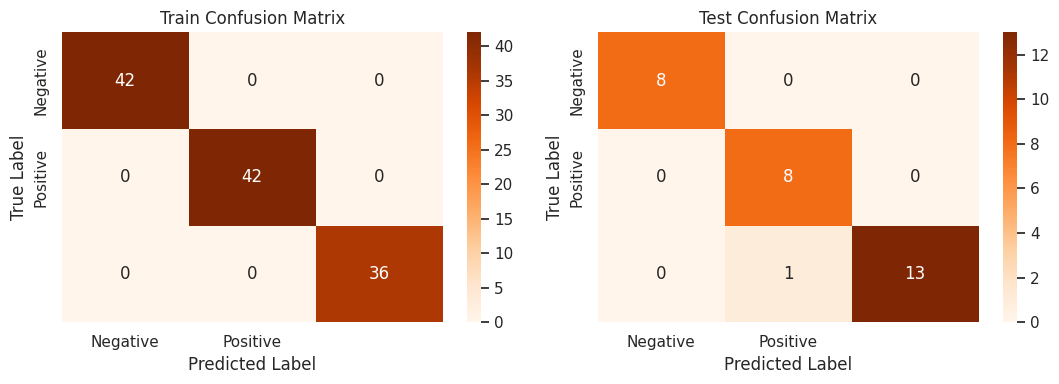

In [46]:
rf_score_opt = evaluate_model(rf_model_opt, x_train, x_test, y_train, y_test)

In [47]:
score['Random Forest Optimized'] = rf_score_opt

In [48]:
score


,Decision Tree,Random Forest,SVM,Random Forest Optimized
Precision Train,1.000000,1.000000,0.975247,1.000000
Precision Test,0.970370,0.970370,1.000000,0.970370
Recall Train,1.000000,1.000000,0.975000,1.000000
Recall Test,0.966667,0.966667,1.000000,0.966667
Accuracy Train,1.000000,1.000000,0.975000,1.000000
Accuracy Test,0.966667,0.966667,1.000000,0.966667
F1 macro Train,1.000000,1.000000,0.975021,1.000000
F1 macro Test,0.967030,0.967030,1.000000,0.967030
